In [1]:
import os
import sys
from pathlib import Path

# setting proper working directory
PROJECT_DIRECTORY = Path(os.path.abspath('')).resolve().parents[0]
sys.path.extend([str(PROJECT_DIRECTORY)])

print(f'Python {sys.version} on {sys.platform}')
print('Project directory: ', PROJECT_DIRECTORY)

Python 3.12.5 (tags/v3.12.5:ff3bc82, Aug  6 2024, 20:45:27) [MSC v.1940 64 bit (AMD64)] on win32
Project directory:  C:\Users\s8347434\Documents\RecBole-GNN\asset


In [2]:
# Define custom colors
tu_dd_blue = (0 / 255, 48 / 255, 93 / 255)
bu_green1 = (138 / 255, 203 / 255, 193 / 255)
bu_green2 = (0 / 255, 172 / 255, 169 / 255)
bu_green3 = (0 / 255, 131 / 255, 141 / 255)
ing_blue1 = (132 / 255, 207 / 255, 237 / 255)
ing_blue2 = (0 / 255, 161 / 255, 217 / 255)
ing_blue3 = (0 / 255, 119 / 255, 174 / 255)
ing_blue4 = (0 / 255, 105 / 255, 180 / 255)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import json

In [4]:
# Function to process columns
def json_dumps_user_columns(df):
    for col in df.columns:
        if col.startswith('best_user_') or col.startswith('worst_user_') or col.endswith('dict'):
            # Apply transformation for each row in the selected columns
            df [col] = df[col].apply(json.dumps)
    return df

# Function to process columns
def json_loads_user_columns(df):
    for col in df.columns:
        if col.startswith('best_user_') or col.startswith('worst_user_') or col.endswith('dict'):
            # Apply transformation for each row in the selected columns
            df [col] = df[col].apply(json.loads)
    return df

In [6]:
EVAL_RUN = "RO"
file_path = f"{EVAL_RUN}/EvaluationData.parquet"
if not os.path.isfile(file_path):
    print("File does not exist, run the BuildEvalDataset.ipynb first")
else:
    print(f"File exists! Load file from {file_path}")
    # Load the existing DataFrame
    final_eval_df = pd.read_parquet(file_path, engine="pyarrow")
    #final_eval_df = json_loads_user_columns(final_eval_df)

File exists! Load file from RO/EvaluationData.parquet


In [9]:
def plot_cluster_centroids(data, model, characteristics, num_datasets, save_fig=False):    
   
    # Filter the data for the selected model
    df = data[data['Model'] == model].copy()

    # Plot centroids as a boxplot
    fig, ax = plt.subplots(1,len(characteristics), layout="constrained", figsize=(16, 6))
    
    for i, characteristic in enumerate(characteristics):
        best_cluster_centroids = []
        worst_cluster_centroids = []
    
        axis = ax[i]
        for index, row in tqdm(df.iloc[:num_datasets].iterrows(), total=num_datasets, unit='rows'):
            if characteristic == 'node_degree':
                ylabel = 'AvgDeg'
                best_cluster_centroids.append(row['best_users_node_degree_mean'])
                worst_cluster_centroids.append(row['worst_users_node_degree_mean'])
            elif characteristic == 'degree_assort':
                ylabel = 'Assort'
                best_cluster_centroids.append(row['degree_assort_best_users'])
                worst_cluster_centroids.append(row['degree_assort_worst_users'])
            elif characteristic == 'average_coefficients':
                ylabel = 'AvgClustC'
                best_cluster_centroids.append(row['average_clustering_coef_dot_best_users'])
                worst_cluster_centroids.append(row['average_clustering_coef_dot_worst_users'])
            elif characteristic == 'average_popularity':
                ylabel = 'ARP'
                best_cluster_centroids.append(row['best_users_mean_popularity_mean'])
                worst_cluster_centroids.append(row['worst_users_mean_popularity_mean'])
                
        # Create a DataFrame for centroids
        df_centroids = pd.DataFrame({
            'Centroid': np.concatenate([best_cluster_centroids, worst_cluster_centroids]),
            'Group': ['$Users^+$'] * len(best_cluster_centroids) + ['$Users^-$'] * len(worst_cluster_centroids)
        })
        
        custom_palette = [tu_dd_blue, bu_green1]
        
        # Plot centroids as a boxplot
        sns.boxplot(data=df_centroids, x='Group', y='Centroid', palette=custom_palette, hue='Group', boxprops=dict(alpha=.3), ax=axis)
        sns.stripplot(data=df_centroids, x='Group', y='Centroid', color=bu_green3, alpha=0.6, jitter=True, ax=axis)
        
        # Customize plot
        axis.set_ylabel(ylabel, fontsize=25, labelpad=10)
        axis.set_xlabel("")
        
        for spine in axis.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.8)
            spine.set_color('black')
    
        # Display grid
        axis.grid(True, which='both', linestyle='--', linewidth=0.8, alpha=0.3, color='gray')
        
        # Customize ticks
        axis.tick_params(axis='x', labelsize=20)
        axis.tick_params(axis='y', labelsize=20)
            
    if save_fig:
        plt.savefig(f"../plots/boxplot_best_worst_users_results.png", dpi=300, transparent=True)
    
    plt.ylabel(ylabel)
    plt.show()

100%|██████████| 176/176 [00:00<00:00, 12574.27rows/s]


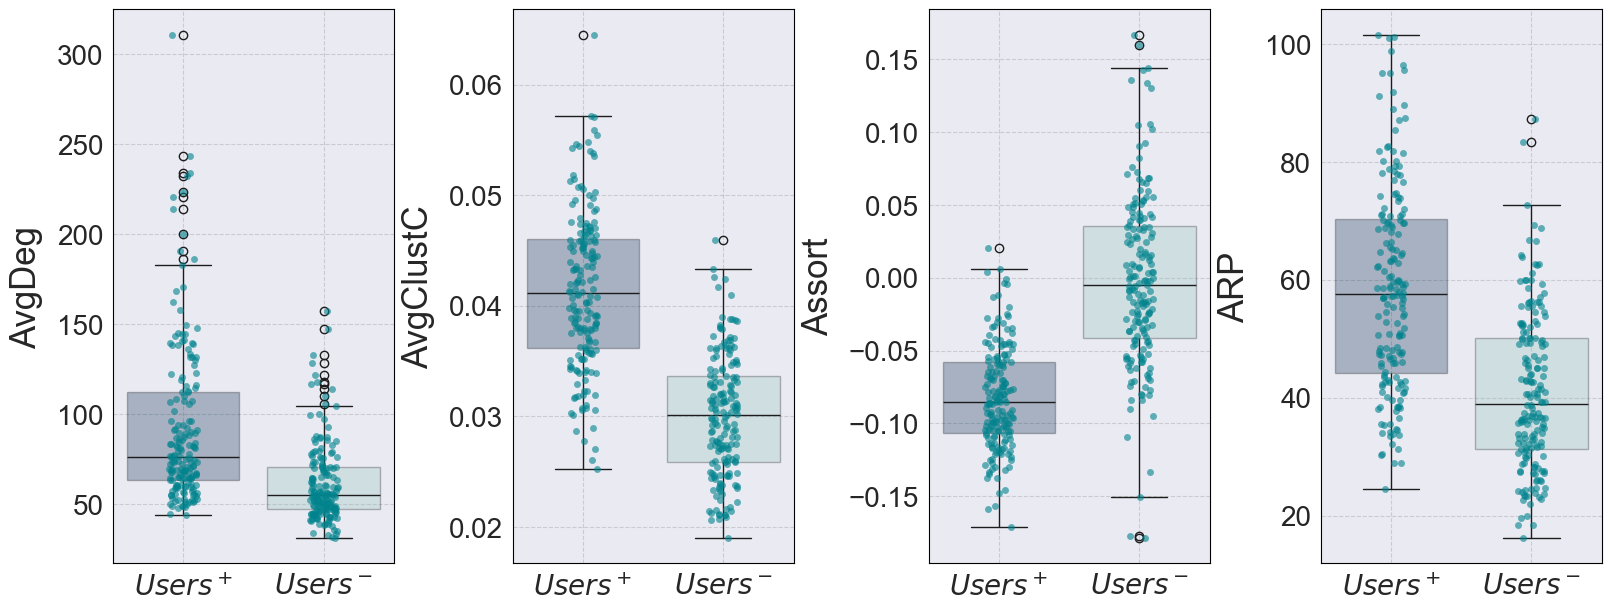

In [10]:
characteristics = ['node_degree', 'average_coefficients', 'degree_assort', 'average_popularity']
model = "ALS"
plot_cluster_centroids(final_eval_df, model=model, characteristics=characteristics, num_datasets=final_eval_df[final_eval_df['Model']==model].shape[0], save_fig=True)